In [131]:
###############
## FUNCTIONS ##
###############

def compute_ensemble_mean_sd(scores_ensemble):    
    """
    """
    scores_ensemble_mu = []
    scores_ensemble_sd = []
    for scores in scores_ensemble:
        scores_ensemble_mu += [scores.mean(2)]
        scores_ensemble_sd += [scores.std(2)]
    return scores_ensemble_mu, scores_ensemble_sd

def compute_ensemble_quantiles(scores_ensemble, q=[0.05,0.5,0.95]):    
    """
    """
    scores_ensemble_qlow = []
    scores_ensemble_qmid = []
    scores_ensemble_qhig = []
    for scores in scores_ensemble:
        scores_ensemble_qlow += [np.quantile(scores,q[0],2)]
        scores_ensemble_qmid += [np.quantile(scores,q[1],2)]
        scores_ensemble_qhig += [np.quantile(scores,q[2],2)]
    return scores_ensemble_qlow, scores_ensemble_qmid, scores_ensemble_qhig 

def load_and_format_ensemble(pti):
    """
    """
    ensemble = []
    model_folders = os.listdir(pti)
    for model_folder in model_folders:
        ensemble += [pickle.load(open(pti + model_folder + "/obj_paw_scores.pkl", "rb"))]
    
    ## Parameters
    num_models = len(ensemble)
    num_samples = len(ensemble[0])
    num_instances_, num_labels = ensemble[0][0].shape
    # dims: (num_models, num_samples, num_instances, num_labels)
    
    ## Re-arrange to have number of models last
    ensemble_new = []
    for j in range(num_samples):    
        ensemble_new += [np.array([ensemble[i][j] for i in range(num_models)]).transpose(1,2,0)]
    ensemble = ensemble_new
    # dims: (num_samples, num_instances, num_labels, num_models)
    
    ## Compute mean and standard deviation
    ensemble_mu, ensemble_sd = compute_ensemble_mean_sd(ensemble)
    ensemble_low, ensemble_mid, ensemble_hig = compute_ensemble_quantiles(ensemble)

    return ensemble_mu, ensemble_low, ensemble_hig

#
###

In [132]:
##############
## INITIATE ##
##############

import os
import cv2
import time
import argparse
import numpy as np
import pickle
import numpy as np
import matplotlib.pyplot as plt

## import modules
from pawmil.f_wsi_reader import slide_path_to_tiles_at_coordinates
from pawmil.f_utils import format_path_file
from pawmil.f_utils import format_label_file
from pawmil.f_visualisations import visualise_scores_map_downsample 

#
###

In [133]:
#############################
## USER DEFINED PARAMETERS ##
#############################

## paths
pt_folder = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/ICGC_annotated_cases/" 
# pt_folder = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/PPCG_MQ_SmallMedium_Nozero_256_MultiTask/" 
pt_subfolder_out = pt_folder + "maps/"
pt_embeddings_in = pt_folder + 'encoder/obj_embeddings.pkl'
pt_tile_coordinates_list = pt_folder + 'preprocessed/obj_tile_coordinates_list.pkl'
pt_path_file = pt_folder + "tab_paths.txt"
pt_label_file = pt_folder + "tab_labels.txt" 
pwd = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/"

## wsi parameters
selected_samples = [0]

#
###

In [134]:
##############
## INITIATE ##
##############

## create output subfolder
if os.path.exists(pt_subfolder_out) == False:
    os.mkdir(pt_subfolder_out)

## get wsi path list and labels and coordinates
wsi_path_list = format_path_file(pt_path_file)
labels = format_label_file(pt_label_file)
tile_coordinate_list = pickle.load(open(pt_tile_coordinates_list, "rb"))
print("loaded coordinates")

#
###

loaded coordinates


In [135]:
############
## CHECKS ##
############

##
print(wsi_path_list)
print(labels)

#
###

['/Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB12.2764_V2_04.svs', '/Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB11.2442_V19_09.svs']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [6]:
######################
## FORMAT PATH LIST ##
######################

##
# wsi_path_list = [wsi_path_list[k].replace("SED","PHD") for k in range(len(wsi_path_list))]

#
###

In [136]:
#################
## FORMAT DATA ##
#################

## Architectures
architectures = ["ICGC_annotated_cases"]
# architectures = ["PPCG_MQ_SmallMedium_Nozero_256_MultiTask"]

## For each architecture
architecture_ensemble_mid = []
architecture_ensemble_low = []
architecture_ensemble_hig = []
architecture_coords = []
architecture_embeds = []
for architecture in architectures:

    ## Load model
    pti = pwd + f"{architecture}/"
    
    ## Load labels
    labels = format_label_file(pti + "tab_labels.txt")

    ## Load coordinates
    coords = pickle.load(open(pti + "encoder/obj_coordinates.pkl", "rb"))

    ## Load embeddings
    embeds = pickle.load(open(pti + "encoder/obj_embeddings.pkl", "rb"))

    ## Load ensemble
    ensemble_mid, ensemble_low, ensemble_hig = load_and_format_ensemble(pti + "aggregator/")
    
    ## Collect
    architecture_ensemble_mid += [ensemble_mid]
    architecture_ensemble_low += [ensemble_low]
    architecture_ensemble_hig += [ensemble_hig]
    architecture_coords += [coords]
    architecture_embeds += [embeds]

#
###

In [137]:
#######################
## FORMAT EMBEDDINGS ##
#######################

## Parameters
selected_architectures = [0]
num_samples = 2 # 413

## Initiate
scores_mu = []
scores_low = []
scores_hig = []
embeds = []

## For each architecture
for m in selected_architectures:

    ## For each sample        
    for i in range(num_samples):

        ## Collect
        scores_mu += [architecture_ensemble_mid[m][i]]
        scores_low += [architecture_ensemble_low[m][i]]
        scores_hig += [architecture_ensemble_hig[m][i]]
        embeds += [architecture_embeds[m][i]]        

## Checks
print(scores_mu[0].shape)
print(embeds[0].shape)
print(coords[0].shape)
print(labels.shape)

#
###

(816, 17)
(816, 128)
(816, 2)
(2, 17)


[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1


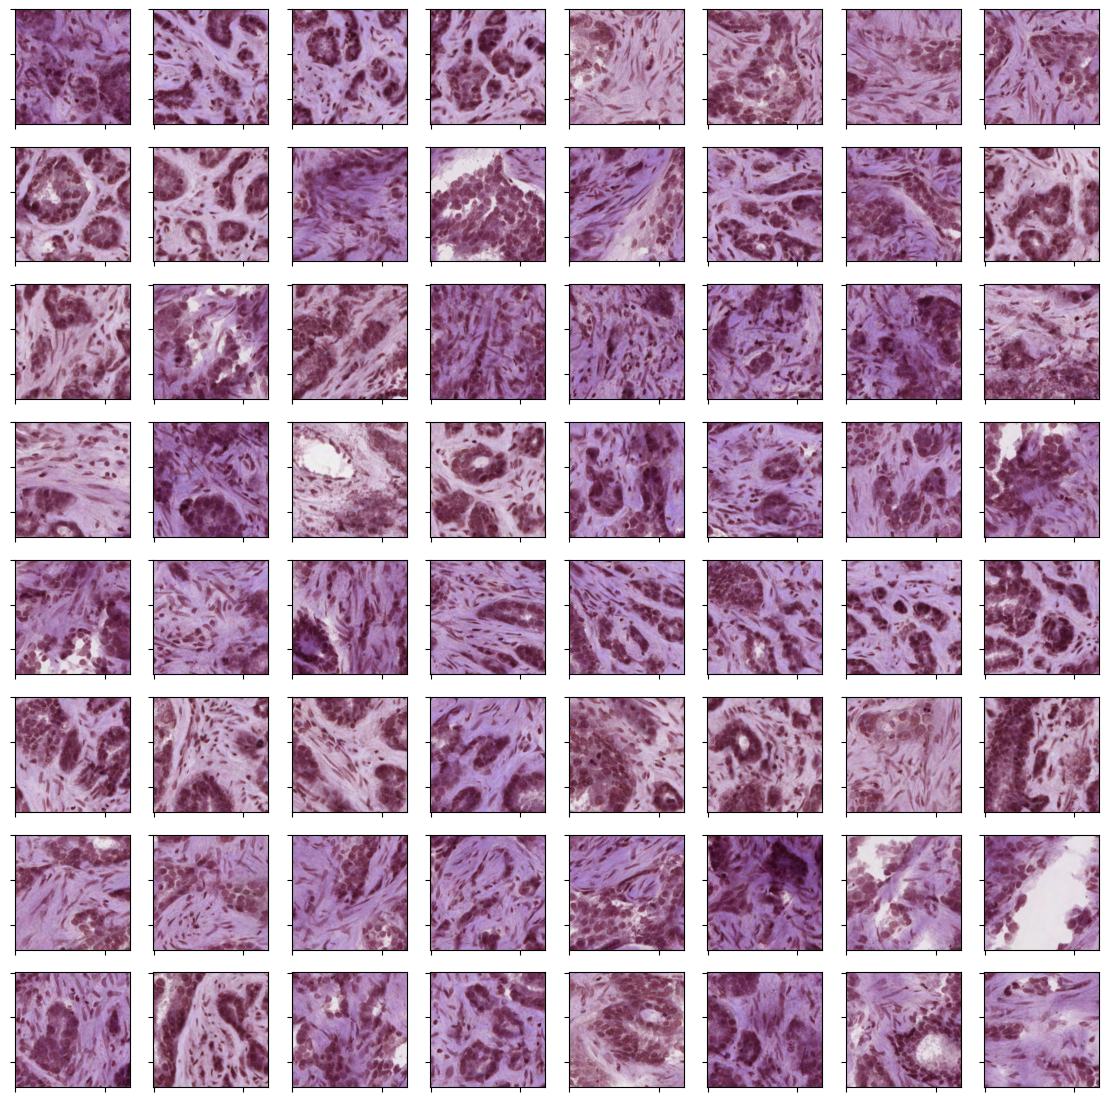

In [138]:
#####################
## VISUALISE TILES ##
#####################

## Parameters
tile_size = 256
level = 0

## Selector
i = 0 # sample
j = 7 # label
print(labels[i])

## get scores
scores_ = np.array((scores_low[i][:,j] > 0) * 1)
s = np.argsort(1-scores_)
print(scores_[s[0]])

## get tiles
tiles = slide_path_to_tiles_at_coordinates(wsi_path_list[i], tile_coordinate_list[i][s], tile_size=tile_size, level=level)

## visualise tiles
k = 0
fig, axs = plt.subplots(8,8, figsize=(14,14))
for i in range(8):
    for j in range(8):        
        axs[i,j].imshow(tiles[k])        
        axs[i,j].set_xticklabels(())
        axs[i,j].set_yticklabels(())
        k += 1
# plt.tight_layout()
plt.show()
plt.close()

#
###

(47, 45)


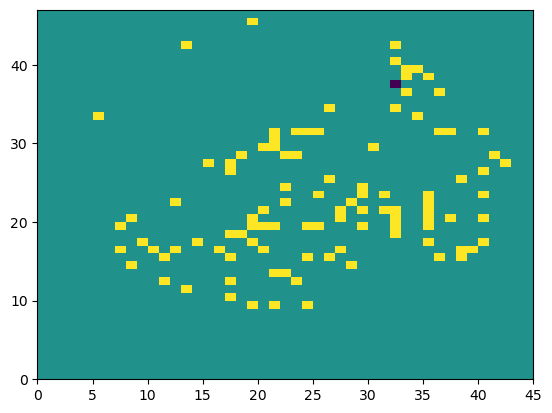

In [139]:
##############
## HEATMAPS ##
##############

##
i = 0
j = 10

## Heatmap
coords_ = (np.array(tile_coordinate_list[i])/256).astype(int)
scores_ = np.array((scores_low[i][:,j] > 0) * 1) - np.array((scores_hig[i][:,j] < 0) * 1)
# scores_ = scores_mu[i][:,j] # np.array((scores_low[i][:,j] > 0) * 1) - np.array((scores_hig[i][:,j] < 0) * 1)
canvas = np.zeros((coords_[:,0].max()+1, coords_[:,1].max()+1))
print(canvas.shape)
k = 0
for k in range(coords_.shape[0]):    
    canvas[coords_[k,0], coords_[k,1]] = scores_[k]
    k += 1
plt.pcolormesh(canvas)
plt.show()
plt.close()

#
###

In [141]:
#######################
## VISUALISE IN SITU ##
#######################

## visualise attention maps
tile_size = 256
level=0
num_classes=17
selected_samples = [0]
if selected_samples != []:
    for i in selected_samples:
        i = i - 1
        print(labels[i])
        tiles = slide_path_to_tiles_at_coordinates(wsi_path_list[i], tile_coordinate_list[i], tile_size=tile_size, level=level)
        for j in range(num_classes):

            ## attention scores
            scores_ = np.array((scores_low[i][:,j] > 0) * 1) - np.array((scores_hig[i][:,j] < 0) * 1)
            visualise_scores_map_downsample(tiles, tile_coordinate_list[i], scores_, 
                pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png", 
                scale=True, mask_inter=False, downsample_factor=8)

#
###

[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [179]:
########################
## PAW MAP VISUALISER ##
########################

def normalise(x):
    """
    """
    return (x - x.min())/(x.max() - x.min())

def visualise_scores_map_downsample_(tiles, coordinates, scores, scale=False, mask_inter=False, downsample_factor=2, alpha=1):
    """
    """
    # Determine dimensions of the original image
    tile_width = tiles[0].shape[0]
    tile_height = tiles[0].shape[1]
    max_x = max(coord[0] for coord in coordinates)
    max_y = max(coord[1] for coord in coordinates)
    image_width = max_x + tile_width  # Assuming the width of each tile is known
    image_height = max_y + tile_height  # Assuming the height of each tile is known

    # Calculate the final downsized image dimensions
    downsized_width = image_width // downsample_factor
    downsized_height = image_height // downsample_factor

    # Resize the tiles and adjust coordinates
    resized_tiles = [cv2.resize(tile, None, fx=1/downsample_factor, fy=1/downsample_factor) for tile in tiles]
    adjusted_coordinates = [(x // downsample_factor, y // downsample_factor) for x, y in coordinates]

    # Initialize the downsized image
    img = np.zeros((downsized_height, downsized_width, 3), dtype=np.uint8)

    # Assemble the image
    for tile, (x, y) in zip(resized_tiles, adjusted_coordinates):
        img[y:y + tile.shape[1], x:x + tile.shape[0]] = tile

    # Convert image to grayscale
    img_mean = img.mean(2)
    for i in range(img.shape[2]):
        img[:,:,i] = img_mean

    # Visualize the scores map
    if scale:
        scores = normalise(scores)
    
    # Create a mask for resizing the scores map
    canvas = np.zeros((downsized_height, downsized_width, 3), dtype=float)
    mask_lo = (scores <= 0.25) # outter-quartile threshold mask
    mask_hi = (scores >= 0.75) # outter-quartile threshold mask
    mask = 1 - np.exp(-0.5*(1/(0.125)**2)*(scores - 0.5)**2) # gaussian mask
    for i, (x, y) in enumerate(adjusted_coordinates):
        if mask_inter: 
            # color = (int(255 * mask_lo[i]), 0, int(255 * mask_hi[i]))  # Assuming attention score is in the range [0, 1]
            color = (int(255 * (1-scores[i]) * mask[i] * (scores[i] < 0.5)), 0, int(255 * scores[i] * mask[i] * (scores[i] >= 0.5)))  # Assuming attention score is in the range [0, 1]
        else:
            color = (int(255 * (1-scores[i])), 0, int(255 * scores[i]))  # Assuming attention score is in the range [0, 1]
        cv2.rectangle(canvas, (x, y), (x + tile_width // downsample_factor, y + tile_height // downsample_factor), color, -1)

    # Blend the scores map with the downsized image
    alpha = 1.0
    img =  (1 - alpha) * img + alpha * canvas    

    # Resize the final image to the desired output size
    img = cv2.resize(img, (1024, 1024))

    # Save the image
    return img

def assemble_map_from_scores(scores, coordinates, tile_size, downsample_factor=2):
    """
    """    
    ## Determine dimensions of the original image
    tile_width = tile_size
    tile_height = tile_size
    max_x = max(coord[0] for coord in coordinates)
    max_y = max(coord[1] for coord in coordinates)
    image_width = max_x + tile_width  # Assuming the width of each tile is known
    image_height = max_y + tile_height  # Assuming the height of each tile is known

    ## Calculate the final downsized image dimensions
    downsized_width = image_width // downsample_factor
    downsized_height = image_height // downsample_factor

    ## Resize the tiles and adjust coordinates
    resized_tiles = [cv2.resize(tile, None, fx=1/downsample_factor, fy=1/downsample_factor) for tile in tiles]
    adjusted_coordinates = [(x // downsample_factor, y // downsample_factor) for x, y in coordinates]
    
    ## Create a mask for resizing the scores map
    canvas = np.zeros((downsized_height, downsized_width, 3), dtype=float)

    ## Assemble
    for i, (x, y) in enumerate(adjusted_coordinates):
        color = (int(255 * scores[i]), int(255 * scores[i]), int(255 * scores[i]))  # Assuming attention score is in the range [0, 1]
        cv2.rectangle(canvas, (x, y), (x + tile_width // downsample_factor, y + tile_height // downsample_factor), color, -1)

    ## Resize the final image to the desired output size
    img = cv2.resize(canvas, (1024, 1024))

    ## Save the image
    return img


def assemble_image_from_tiles(tiles, coordinates, downsample_factor=2):
    """
    """
    ## Determine dimensions of the original image
    tile_width = tiles[0].shape[0]
    tile_height = tiles[0].shape[1]
    max_x = max(coord[0] for coord in coordinates)
    max_y = max(coord[1] for coord in coordinates)
    image_width = max_x + tile_width  # Assuming the width of each tile is known
    image_height = max_y + tile_height  # Assuming the height of each tile is known

    ## Calculate the final downsized image dimensions
    downsized_width = image_width // downsample_factor
    downsized_height = image_height // downsample_factor

    ## Resize the tiles and adjust coordinates
    resized_tiles = [cv2.resize(tile, None, fx=1/downsample_factor, fy=1/downsample_factor) for tile in tiles]
    adjusted_coordinates = [(x // downsample_factor, y // downsample_factor) for x, y in coordinates]

    ## Initialize the downsized image
    img = np.zeros((downsized_height, downsized_width, 3), dtype=np.uint8)

    ## Assemble the image
    for tile, (x, y) in zip(resized_tiles, adjusted_coordinates):
        img[y:y + tile.shape[1], x:x + tile.shape[0]] = tile

    # ## Convert image to grayscale
    # img_mean = img.mean(2)
    # for i in range(img.shape[2]):
    #     img[:,:,i] = img_mean

    ## Resize the final image to the desired output size
    img = cv2.resize(img, (1024, 1024))

    ## Save the image
    return img

def assemble_image_from_path(path, tile_coordinates, tile_size, level, downsample_factor=2):
    """
    """
    ## Number of tiles
    num_tiles_x = int(tile_coordinates[:,0].max(0)/tile_size) + 1
    num_tiles_y = int(tile_coordinates[:,1].max(0)/tile_size) + 1
    
    ## Get coordinates
    coordinates = []
    for i in range(num_tiles_x):
        for j in range(num_tiles_y):
            x_ = i * tile_size
            y_ = j * tile_size
            coordinates += [np.array([x_, y_])]    
    
    ## Get tiles
    tiles = slide_path_to_tiles_at_coordinates(path, coordinates, tile_size=tile_size, level=level)    
    
    ## Assemble image
    img = assemble_image_from_tiles(tiles, coordinates)    

    ## End
    return img
    
#
###

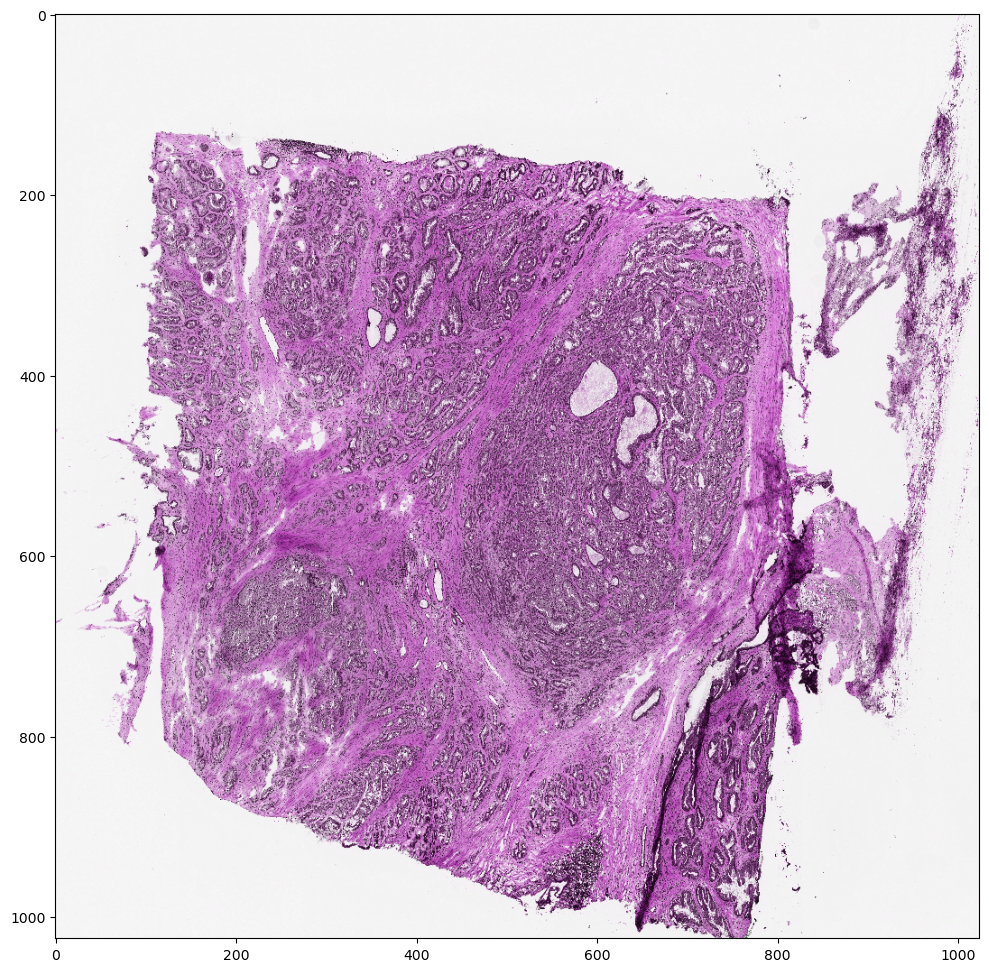

In [165]:
############################
## VISUALISE WHOLE SAMPLE ##
############################

## Parameters
tile_size = 256
level = 0
downsample_factor = 8
selected_sample = 1

## Assemble image
img = assemble_image_from_path(path = wsi_path_list[selected_sample],
                               tile_coordinates = tile_coordinate_list[selected_sample],
                               tile_size = tile_size, 
                               level = level, 
                               downsample_factor = downsample_factor)

## Initiate figure
fig = plt.figure(figsize=(12, 12))  # Create a figure with 1 row and 2 columns for subplots
fontsize = 20
pointsize = 1*16

## Show image
img_ = img
img_[:,:,0] = img[:,:,2]
img_[:,:,2] = img[:,:,0]
img_ = (img_-img.min())/(img_.max()-img.min())*1#.reshape(img_.shape[0],img_.shape[1],1)
plt.imshow(img_)
# pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png"

## End
plt.show()
plt.tight_layout()
plt.close()

#
###

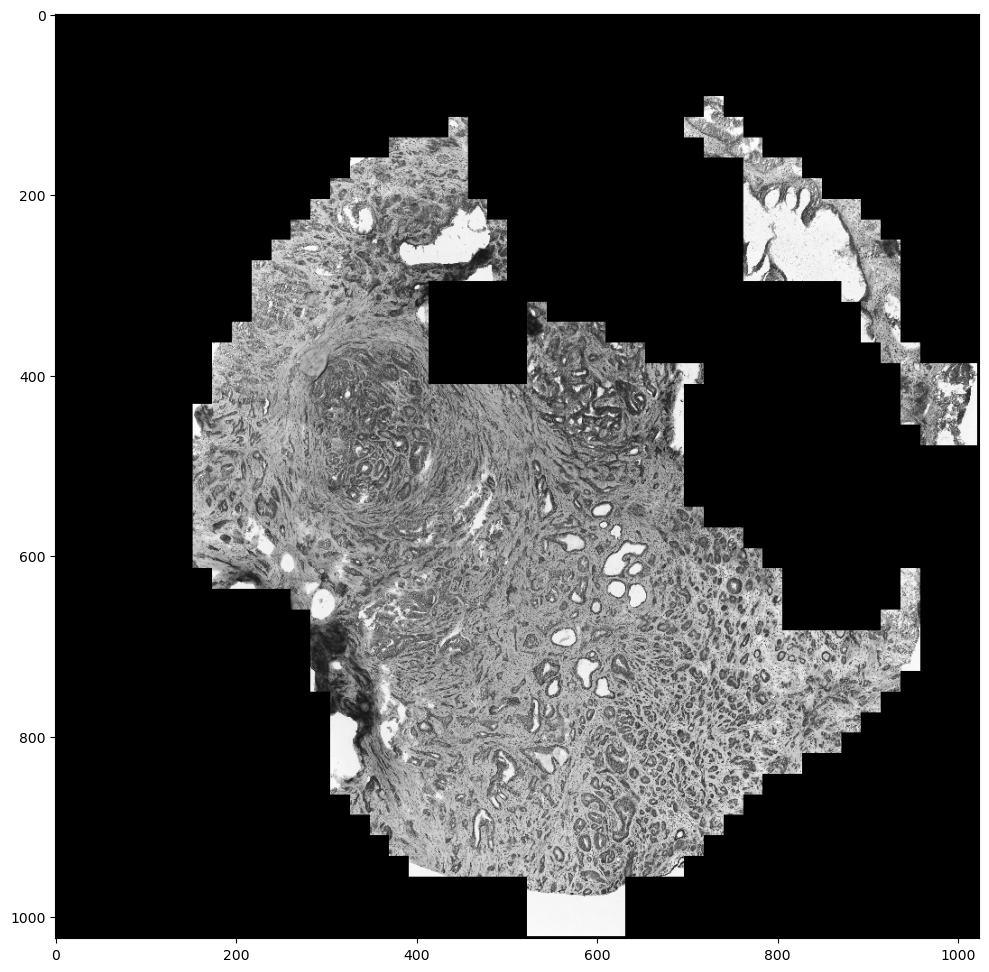

In [77]:
##############################
## VISUALISE FILTERED TILES ##
##############################

## Get tiles
tiles = slide_path_to_tiles_at_coordinates(wsi_path_list[selected_sample], tile_coordinate_list[selected_sample], tile_size=tile_size, level=level)

## Assemble image
img = assemble_image_from_tiles(tiles, tile_coordinate_list[selected_sample])

## Initiate figure
fig = plt.figure(figsize=(12, 12))  # Create a figure with 1 row and 2 columns for subplots
fontsize = 20
pointsize = 1*16

## Show image
img_ = img
img_[:,:,0] = img[:,:,2]
img_[:,:,2] = img[:,:,0]
img_ = (img_-img.min())/(img_.max()-img.min())*1#.reshape(img_.shape[0],img_.shape[1],1)
plt.imshow(img_)
# pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png"

## End
plt.show()
plt.tight_layout()
plt.close()

#
###

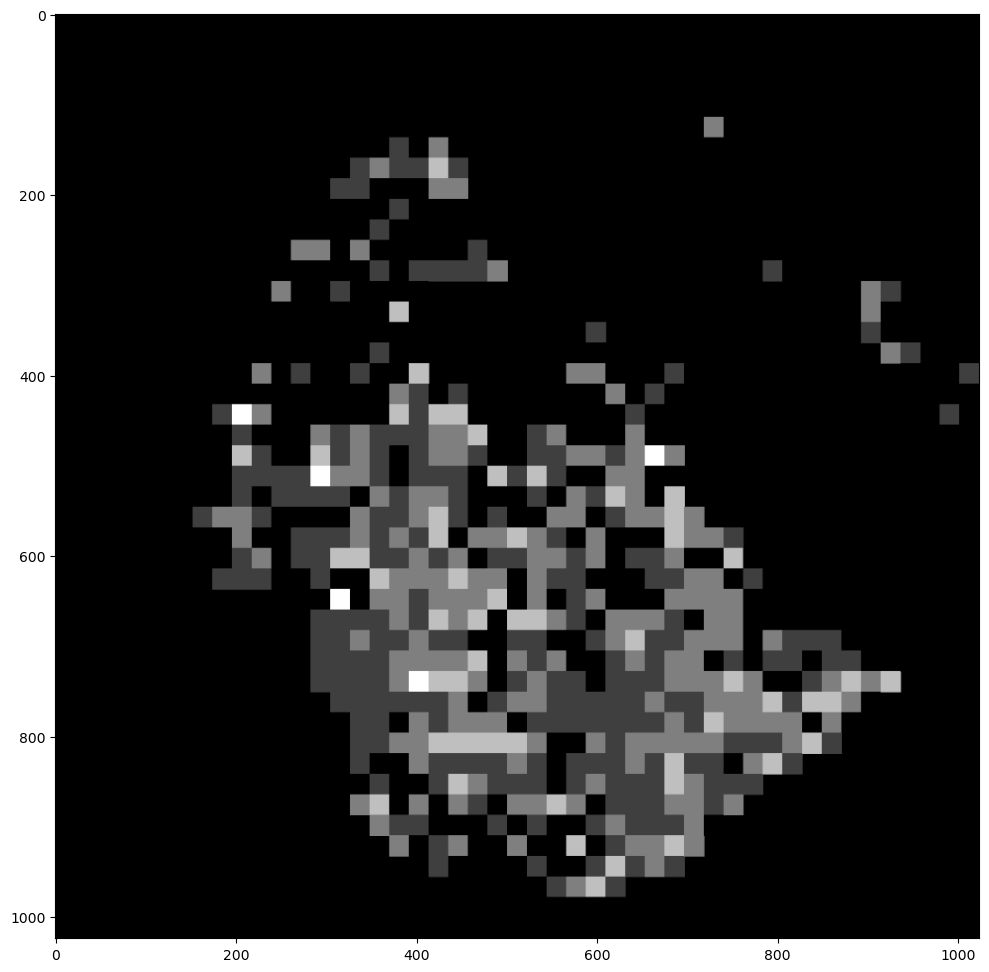

In [162]:
###########################
## VISUALISE IN PAW MAPS ##
###########################

## Parameters
tile_size = 256
level = 0
downsample_factor = 8
selected_samples = [0]
selected_labels = [0, 5, 9, 10] # Lethal signature
# selected_class = [6, 7, 8, 11, 12, 13, 14, 15, 16] # Other signature

## For each sample
for i in selected_samples:    
    
    ## Compute scores
    scores_p = []
    scores_n = []
    for j in selected_class:
        scores_p_ = np.array((scores_low[i][:,j] > 0) * 1)
        scores_n_ = np.array((scores_hig[i][:,j] < 0) * 1)
        scores_p += [scores_p_]        
        scores_n += [scores_n_]        
    scores_p = np.stack(scores_p).sum(0)
    scores_n = np.stack(scores_n).sum(0)
    scores_ = scores_p # - scores_n

    ## Map
    img = assemble_map_from_scores(scores_, tile_coordinate_list[i], 
                                   tile_size = 256, 
                                   downsample_factor = 8)

## Initiate figure
fig = plt.figure(figsize=(12, 12))  # Create a figure with 1 row and 2 columns for subplots
fontsize = 20
pointsize = 1*16

## Show image
img_ = img
img_[:,:,0] = img[:,:,2]
img_[:,:,2] = img[:,:,0]
img_ = (img_-img.min())/(img_.max()-img.min())*1#.reshape(img_.shape[0],img_.shape[1],1)
plt.imshow(img_)
# pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png"

## End
plt.show()
plt.tight_layout()
plt.close()


#
###

In [182]:
#################################
## VISUALISE COMBINED PAW MAPS ##
#################################

## Parameters
tile_size = 256
level = 0
downsample_factor = 8
selected_samples = [0]
selected_labels_1 = [0, 5, 9, 10] # Lethal signature
selected_labels_2 = [6, 7, 8, 11, 12, 13, 14, 15, 16] # Other signature

## For each sample
for i in selected_samples:    
    
    ## Compute scores
    scores_p = []
    for j in selected_labels_1:
        scores_p_ = np.array((scores_low[i][:,j] > 0) * 1)        
        scores_p += [scores_p_]                
    scores_p = np.stack(scores_p).sum(0)    
    scores_1 = scores_p

    ## Compute scores
    scores_p = []
    for j in selected_labels_2:
        scores_p_ = np.array((scores_low[i][:,j] > 0) * 1)        
        scores_p += [scores_p_]                
    scores_p = np.stack(scores_p).sum(0)    
    scores_2 = scores_p

    ## Map
    map_1 = assemble_map_from_scores(scores_1, tile_coordinate_list[i], 
                                   tile_size = 256, 
                                   downsample_factor = 8)

    ## Map
    map_2 = assemble_map_from_scores(scores_2, tile_coordinate_list[i], 
                                   tile_size = 256, 
                                   downsample_factor = 8)
    
    ## Assemble image
    img = assemble_image_from_path(path = wsi_path_list[i], 
                                   tile_coordinates = tile_coordinate_list[i], 
                                   tile_size = tile_size, 
                                   level = level, 
                                   downsample_factor = downsample_factor)

    

In [190]:
########################
## VISUALISE PAW MAPS ##
########################

## Parameters
brightness = 1.4
alpha = 0.7

## Normalise
map_1_ = map_1/map_1.max()
map_2_ = map_2/map_2.max()
img_ = img/img.max()

## Combine
img_[:,:,2] = img_[:,:,2] + map_1_[:,:,2] * alpha

## Normalse again
img_ = (img_-img.min())/(img_.max()-img.min())*1

## Save
pt_subfolder_out = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/ICGC_annotated_cases/maps/"
cv2.imwrite(pt_subfolder_out + "img_agg_sample_" + str(i) + "_map_1.png", img_ * 255 * brightness)

## Normalise
map_1_ = map_1/map_1.max()
map_2_ = map_2/map_2.max()
img_ = img/img.max()

## Combine
img_[:,:,1] = img_[:,:,1] + map_2_[:,:,1] * alpha

## Normalse again
img_ = (img_-img.min())/(img_.max()-img.min())*1

## Save
pt_subfolder_out = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/ICGC_annotated_cases/maps/"
cv2.imwrite(pt_subfolder_out + "img_agg_sample_" + str(i) + "_map_2.png", img_ * 255 * brightness)

## Normalise
map_1_ = map_1/map_1.max()
map_2_ = map_2/map_2.max()
img_ = img/img.max()

## Combine
img_[:,:,2] = img_[:,:,2] + map_1_[:,:,2] * alpha
img_[:,:,1] = img_[:,:,1] + map_2_[:,:,1] * alpha

## Normalse again
img_ = (img_-img.min())/(img_.max()-img.min())*1

## Save
pt_subfolder_out = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/ICGC_annotated_cases/maps/"
cv2.imwrite(pt_subfolder_out + "img_agg_sample_" + str(i) + "_map_1_and_2.png", img_ * 255 * brightness)

#
###

True

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


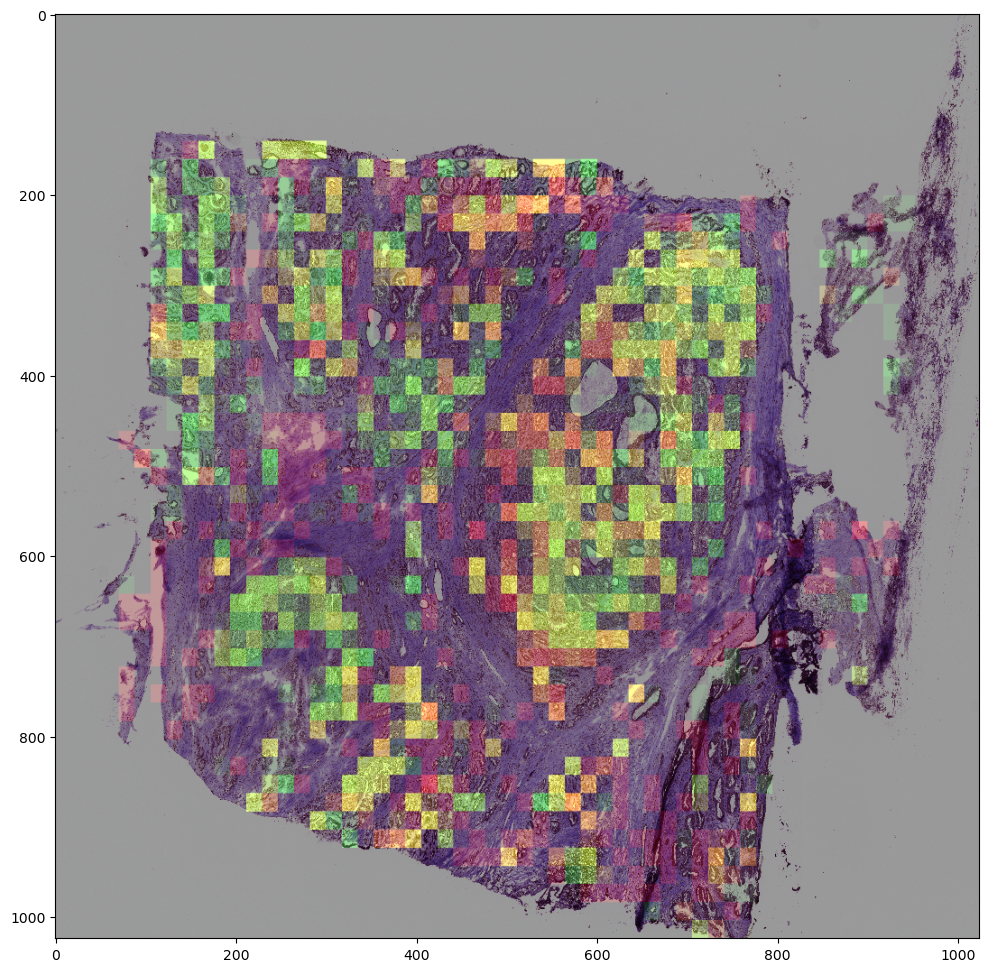

In [167]:
########################
## VISUALISE PAW MAPS ##
########################

## Normalise
map_1_ = map_1/map_1.max()
map_2_ = map_2/map_2.max()
img_ = img/img.max()

## Combine
# img_ = img_ + map_
img_[:,:,0] = img_[:,:,0] + map_1_[:,:,0]
img_[:,:,1] = img_[:,:,1] + map_2_[:,:,1]

## Normalse again
img_ = (img_-img.min())/(img_.max()-img.min())*1

## Initiate figure
fig = plt.figure(figsize=(12, 12))
fontsize = 20
brightness = 1.25

## Show image
plt.imshow(img_ * brightness)

## End
plt.show()
plt.tight_layout()
plt.close()

#
###

[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


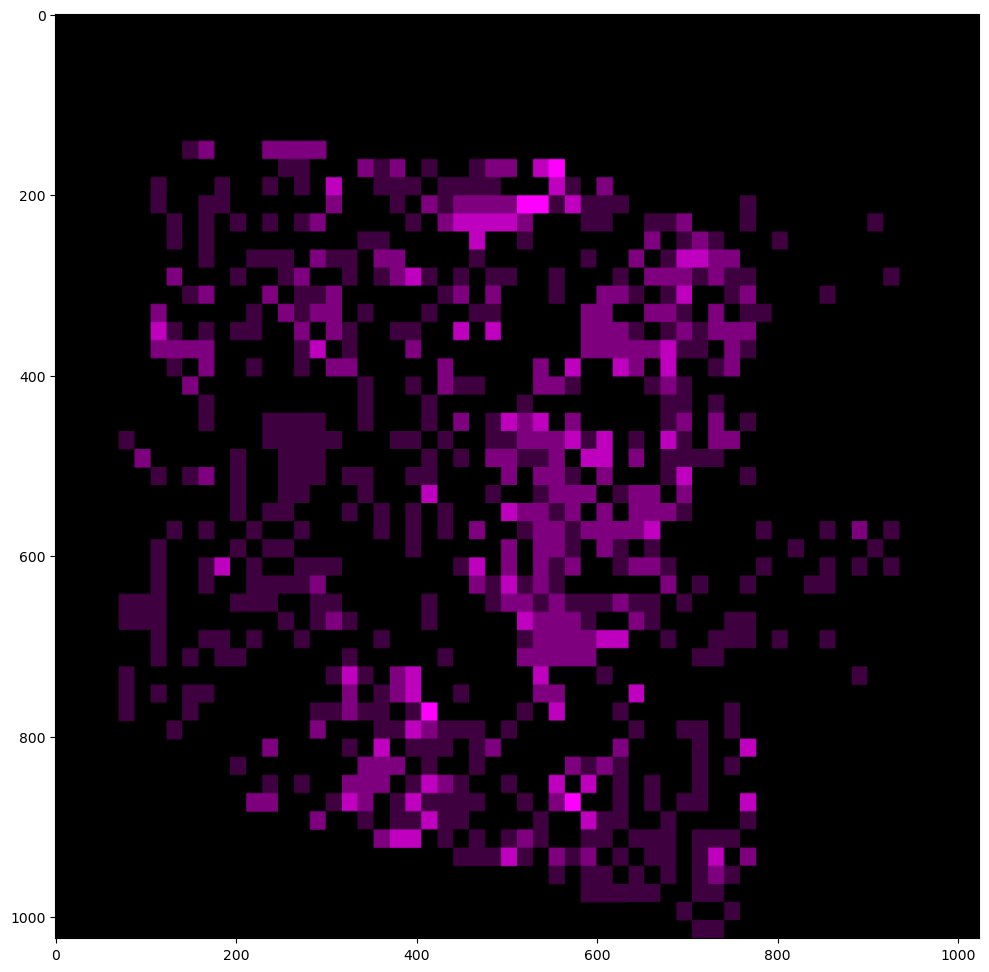

True

In [57]:
###########################
## VISUALISE IN PAW MAPS ##
###########################

## Parameters
tile_size = 256
level = 0
selected_samples = [0]
selected_class = [0, 5, 9, 10] # Lethal signature
# selected_class = [6, 7, 8, 11, 12, 13, 14, 15, 16] # Other signature

## visualise paw maps
if selected_samples != []:
    for i in selected_samples:
        i = i - 1
        print(labels[i])

        ## Get tiles
        tiles = slide_path_to_tiles_at_coordinates(wsi_path_list[i], tile_coordinate_list[i], tile_size=tile_size, level=level)

        ## Compute scores
        scores_p = []
        scores_n = []
        for j in selected_class:
            scores_p_ = np.array((scores_low[i][:,j] > 0) * 1)
            scores_n_ = np.array((scores_hig[i][:,j] < 0) * 1)
            scores_p += [scores_p_]        
            scores_n += [scores_n_]        
        scores_p = np.stack(scores_p).sum(0)
        scores_n = np.stack(scores_n).sum(0)
        scores_ = scores_p # - scores_n
        
        ## Image
        img = visualise_scores_map_downsample_(tiles, tile_coordinate_list[i], scores_,
                scale=True, mask_inter=False, downsample_factor=8, alpha=1.0)

## Initiate figure
fig = plt.figure(figsize=(12, 12))  # Create a figure with 1 row and 2 columns for subplots
fontsize = 20
pointsize = 1*16

## Show image
img_ = img
img_[:,:,0] = img[:,:,2]
img_[:,:,2] = img[:,:,0]
img_ = (img_-img.min())/(img_.max()-img.min())*1#.reshape(img_.shape[0],img_.shape[1],1)
plt.imshow(img_)
# pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png"

## End
plt.show()
plt.tight_layout()
plt.close()

## Save
pt_subfolder_out = "/Users/willembonnaffe/Library/CloudStorage/OneDrive-Nexus365/BDI/projects/PAWMIL-2D/b2_2_2/ICGC_annotated_cases/maps/"
cv2.imwrite(pt_subfolder_out + "img_agg_sample_" + str(i+1) + "_class_" + str(j+1) + "_paw_map.png", img)

#
###